In [1]:
import os 
import pandas as pd
import glob
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
from utils import * 

# 1D cases analysis

In [2]:
log1d_paths = glob.glob('../logs/exp1d/*/*/*.csv')

In [3]:
log1d_df = load_accuracy_log(log1d_paths)

100%|██████████| 17327/17327 [00:00<00:00, 211440.08it/s]


## select the best five result from test_l2

### trend on different residual type without coarsen

In [4]:
filt = []
not_enough = []
for model in ['fno1d', 'lno1d', 'ft1d', 'gt1d']:
    for dataset in ['cosine', 'burgers', 'lnabs']:
        for coarse_level in [0, 1, 2, 3, 4]:
            for residual in ['null', 'diag', 'ml1', 'ml2', 'ml3', 'ml4']:
                for resolution in [512, 1024, 2048, 4096, 8192]:
                    sub_df = log1d_df[(log1d_df.model == model) & (log1d_df.dataset == dataset) & (log1d_df.coarse_level == coarse_level) & (log1d_df.residual == residual) & (log1d_df.resolution == resolution)]
                    filt_df = sub_df.sort_values(by='seed').iloc[:5]
                    if (filt_df.shape[0] < 5) & (coarse_level == 4):
                        not_enough.append([model, dataset, coarse_level, residual, resolution, best_df.seed.tolist()])
                    
                    filt.append(filt_df)

log1d_filt_df = pd.concat(filt)

### Visualize All type model with no coarsen and fix residual(null, diag, ml4)

In [5]:
# fig = vis1d_all_model_dataset_result(log1d_filt_df, ml='ml2')

### All type model with all type residuals and no coarsen with different resolutions

In [6]:
# for dataset in ['lnabs', 'cosine', 'burgers', 'poisson']:

#     print('='*80)
#     print(dataset)
#     print('='*80)

#     for model in ['fno1d', 'lno1d', 'ft1d', 'gt1d']:
#         clevel=0
#         sub_df = log1d_df[(log1d_df.dataset == dataset) & (log1d_df.coarse_level == clevel) & (log1d_df.model == model)]
#         l2_mean = sub_df.groupby(["model", "dataset", "coarse_level", "resolution", "residual"])['test_l2'].apply(np.mean).reset_index()
#         l2_min = sub_df.groupby(["model", "dataset", "coarse_level", "resolution", "residual"])['test_l2'].apply(np.min).reset_index()
#         l2_max = sub_df.groupby(["model", "dataset", "coarse_level", "resolution", "residual"])['test_l2'].apply(np.max).reset_index()
        
#         print(l2_mean.pivot_table(values='test_l2', index=['model', 'residual'], columns=['resolution']))    

### All type model with all type residuals and no coarsen on 4096

In [7]:
import matplotlib.pyplot as plt 
import matplotlib as mpl

In [8]:
sub_df = log1d_filt_df[(log1d_filt_df.resolution == 4096) & (log1d_filt_df.coarse_level == 0)]
table_4096_c0 = sub_df.pivot_table(values='test_l2', index=['dataset', 'model'], columns=['residual'])
column_order = ['null', 'diag', 'ml1', 'ml2', 'ml3', 'ml4']
table_4096_c0.reindex(column_order, axis=1).round(4)

residual         null    diag     ml1     ml2     ml3     ml4
dataset model                                                
burgers fno1d  0.0052  0.0039  0.0043  0.0046  0.0049  0.0056
        ft1d   0.0312  0.0265  0.0272  0.0231  0.0209  0.0174
        gt1d   0.0350  0.0359  0.0379  0.0340  0.0240  0.0174
        lno1d  0.0502  0.0223  0.0215  0.0246  0.0272  0.0317
cosine  fno1d  0.0200  0.0224  0.0215  0.0214  0.0205  0.0204
        ft1d   0.0117  0.0145  0.0149  0.0139  0.0097  0.0110
        gt1d   0.0230  0.0213  0.0193  0.0194  0.0231  0.0219
        lno1d  0.0401  0.0060  0.0055  0.0055  0.0059  0.0056
lnabs   fno1d  0.0178  0.0125  0.0118  0.0107  0.0103  0.0101
        ft1d   0.0426  0.0438  0.0410  0.0387  0.0281  0.0221
        gt1d   0.0464  0.0304  0.0332  0.0271  0.0246  0.0180
        lno1d  0.0452  0.0238  0.0269  0.0259  0.0247  0.0211

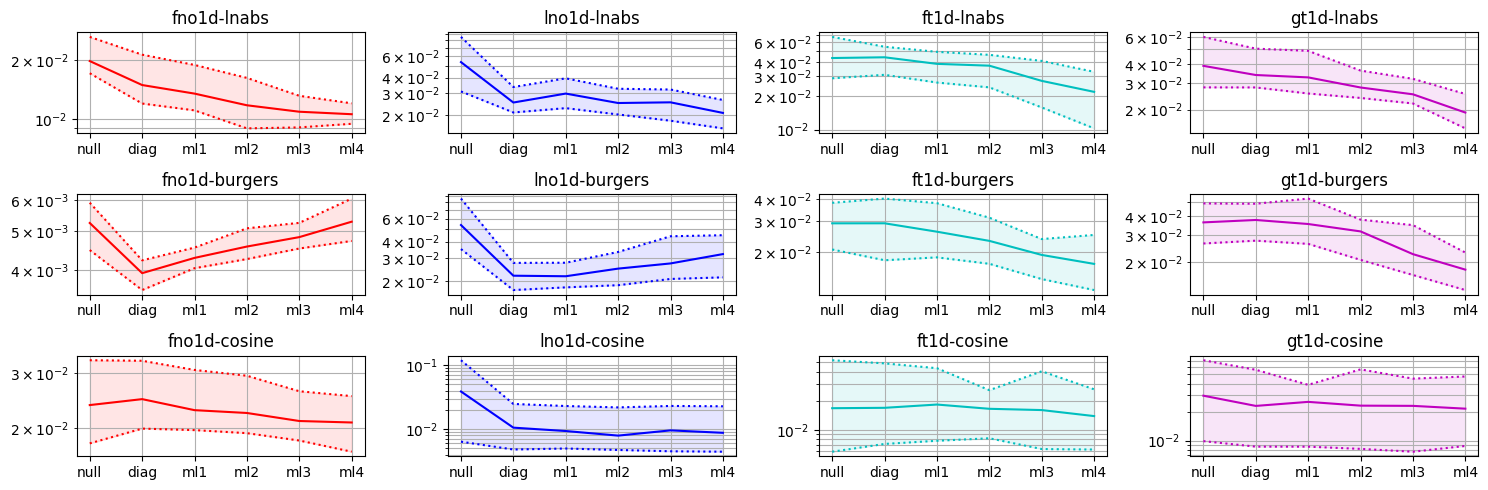

In [9]:
fig = vis_all_model_dataset_residual_trend_on_fix_resolution(log1d_filt_df, resolution=4096)

### All type model with all coarsen and diag-ml4 on 4096

In [10]:
sub_df = log1d_filt_df[(log1d_filt_df.resolution == 4096) & (log1d_filt_df.residual == 'diag')]
table_mean = sub_df.pivot_table(values='test_l2', index=['dataset', 'model'], columns=['coarse_level'], aggfunc=np.mean)
table_min = sub_df.pivot_table(values='test_l2', index=['dataset', 'model'], columns=['coarse_level'], aggfunc=np.min)
table_max = sub_df.pivot_table(values='test_l2', index=['dataset', 'model'], columns=['coarse_level'], aggfunc=np.max)

In [11]:
table_mean.round(4)

coarse_level        0       1       2       3       4
dataset model                                        
burgers fno1d  0.0039  0.0039  0.0039  0.0039  0.0040
        ft1d   0.0265  0.0328  0.0316  0.0282  0.0271
        gt1d   0.0359  0.0372  0.0396  0.0365  0.0400
        lno1d  0.0223  0.0220  0.0217  0.0206  0.0226
cosine  fno1d  0.0224  0.0220  0.0243  0.0245  0.0307
        ft1d   0.0145  0.0128  0.0118  0.0160  0.0294
        gt1d   0.0213  0.0155  0.0240  0.0191  0.0362
        lno1d  0.0060  0.0056  0.0080  0.0114  0.0219
lnabs   fno1d  0.0125  0.0126  0.0132  0.0153  0.0208
        ft1d   0.0438  0.0396  0.0475  0.0451  0.0444
        gt1d   0.0304  0.0341  0.0325  0.0322  0.0395
        lno1d  0.0238  0.0245  0.0247  0.0247  0.0286

### trend on same resolution with different coarsen level

NameError: name 'mpl' is not defined

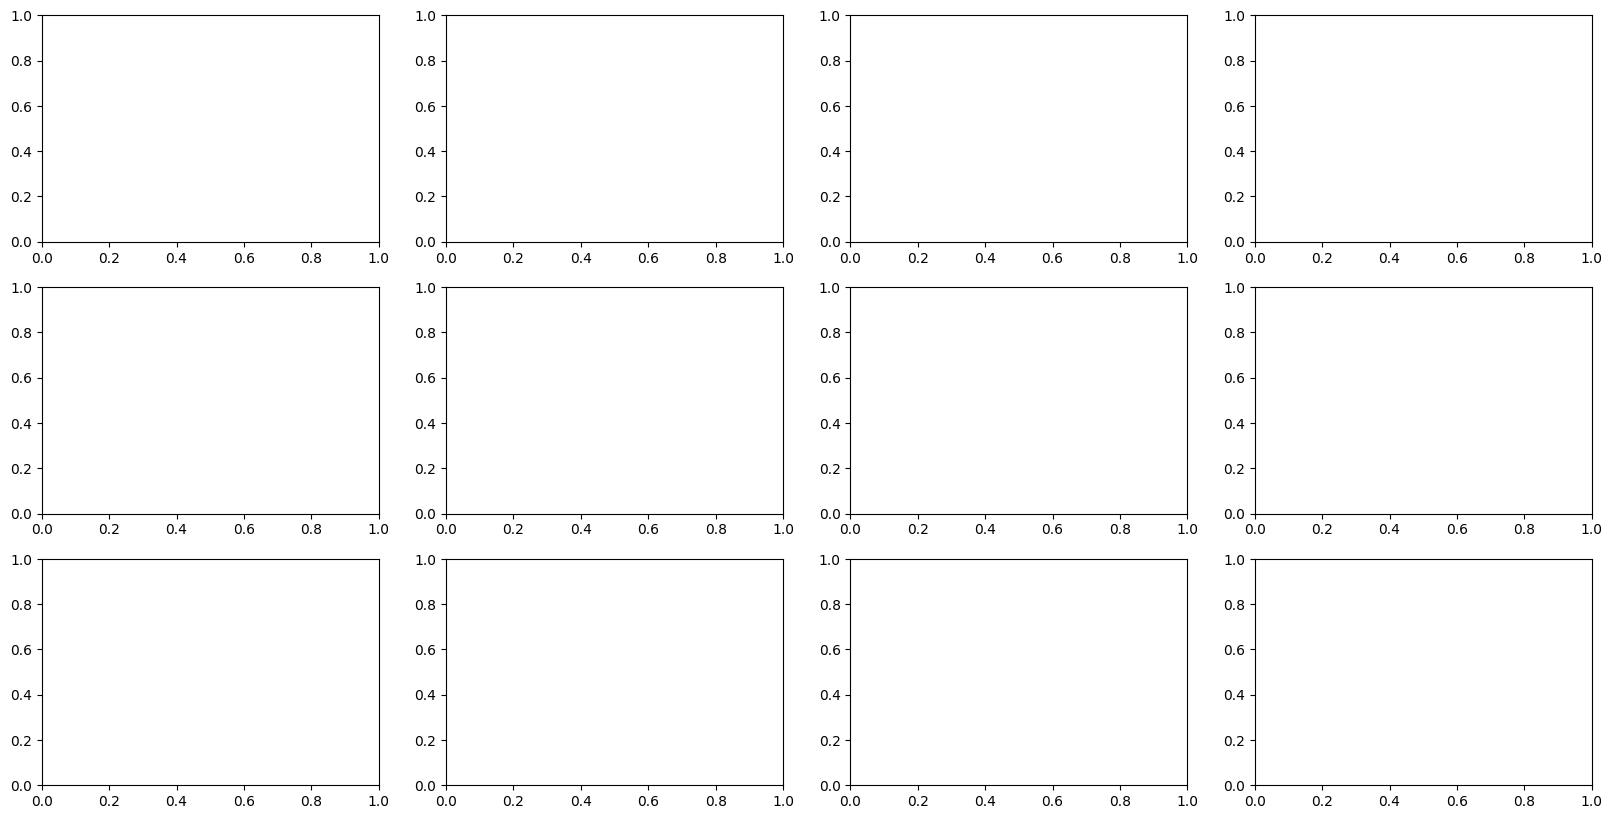

In [12]:
vis_all_model_dataset_residual_trend_on_fix_resolution_and_coarse_level(log1d_filt_df, resolution=4096)

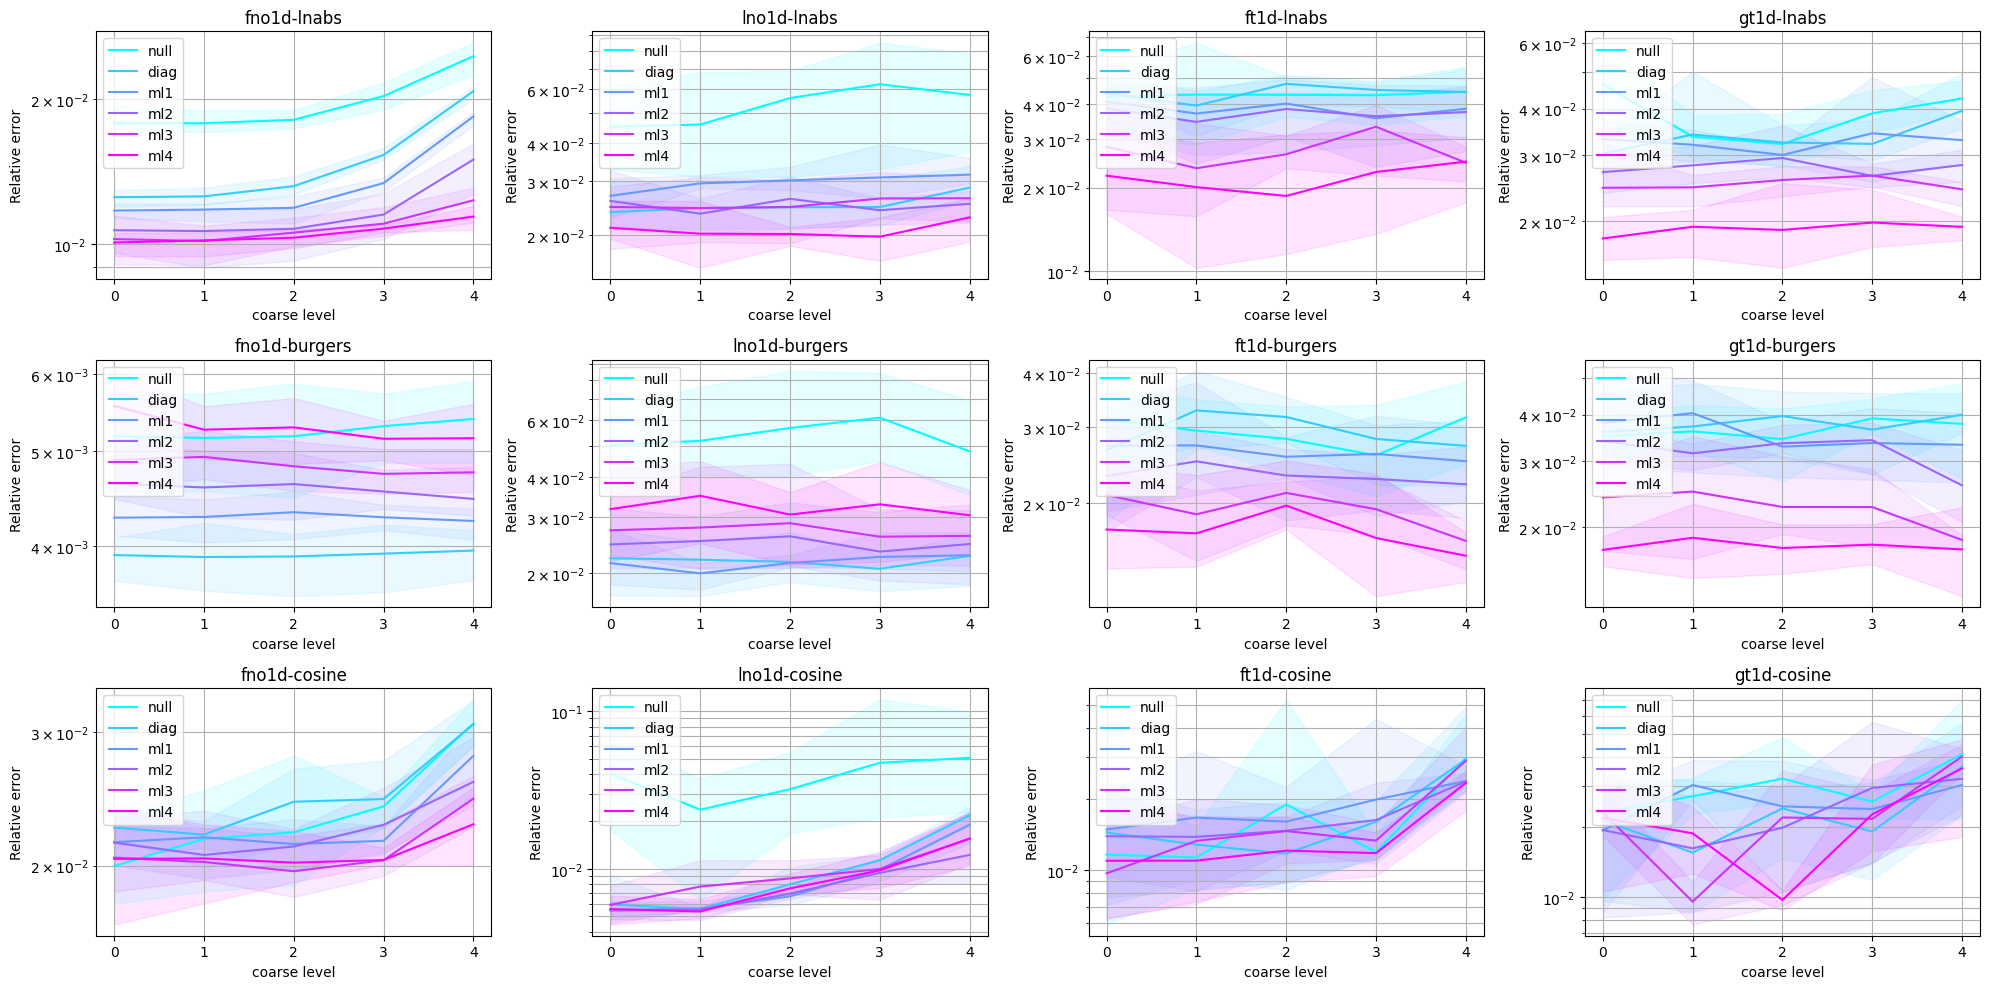

In [23]:
fig, axs = plt.subplots(3, 4, figsize=(20, 10))#, sharey='row')
sub_df = log1d_filt_df[log1d_filt_df.resolution == 4096]
colors = mpl.colormaps['cool']
coarse_levels = [0, 1, 2, 3, 4]
for m, model in enumerate(['fno1d', 'lno1d', 'ft1d', 'gt1d']):
    for d, dataset in enumerate(['lnabs', 'burgers', 'cosine']):
        subsub_df = sub_df[(sub_df.model == model) & (sub_df.dataset == dataset)]            
        table_mean = subsub_df.pivot_table(values='test_l2', index=['coarse_level'], columns=['residual'], aggfunc=np.mean)
        table_min = subsub_df.pivot_table(values='test_l2', index=['coarse_level'], columns=['residual'], aggfunc=np.min)
        table_max = subsub_df.pivot_table(values='test_l2', index=['coarse_level'], columns=['residual'], aggfunc=np.max)
        
        for r, residual in enumerate(['null', 'diag', 'ml1', 'ml2', 'ml3', 'ml4']):
            # axs[d][m].plot(table_mean.index, table_min[[residual]].values.reshape(-1), ":",color=colors(r*0.2))
            # axs[d][m].plot(table_mean.index, table_max[[residual]].values.reshape(-1), ":",color=colors(r*0.2))
            axs[d][m].plot(table_mean.index, table_mean[[residual]].values.reshape(-1), "-",color=colors(r*0.2), label=residual)
            axs[d][m].fill_between(table_mean.index, 
                                   table_min[[residual]].values.reshape(-1),
                                   table_max[[residual]].values.reshape(-1), color=colors(r*0.2), alpha=0.1)
            
        axs[d][m].set_xticks(coarse_levels)
        axs[d][m].set_xticklabels(coarse_levels)
        axs[d][m].set_title("{:}-{:}".format(model, dataset))
        axs[d][m].set_yscale('log')
        axs[d][m].grid(axis='both', which='both')
        axs[d][m].legend(loc='upper left')
        axs[d][m].set_xlabel('coarse level')
        axs[d][m].set_ylabel('Relative error')
        
fig.tight_layout()

### trend on different residual type on different coarsen level

In [14]:
# model1d_df = log1d_agg_df[(log1d_agg_df.model == 'ft1d')]
# model1d_table = pd.pivot_table(model1d_df, values='test_l2', index=['resolution', 'residual'], columns=['dataset', 'coarse_level'])
# model1d_table = model1d_table.reindex(
#     pd.MultiIndex.from_product(
#         [model1d_table.index.levels[0], ['null','diag','ml1', 'ml2', 'ml3', 'ml4']]), axis=0)

In [15]:
# for model_nm in ['ft1d', 'gt1d', 'fno1d', 'lno1d']:
#     model1d_df = log1d_agg_df[(log1d_agg_df.model == model_nm)]
#     model1d_table = pd.pivot_table(model1d_df, values='test_l2', index=['resolution', 'residual'], columns=['dataset', 'coarse_level'])
#     model1d_table = model1d_table.reindex(
#         pd.MultiIndex.from_product(
#             [model1d_table.index.levels[0], ['null','diag','ml1', 'ml2', 'ml3', 'ml4']]), axis=0)

#     fig = plt.figure(figsize=(40, 10))
#     fig.suptitle(model_nm)
#     fig.subplots_adjust(top=0.95)
    
#     bmin = model1d_table['burgers'].min().min()
#     bmax = model1d_table['burgers'].max().max()
#     plt.subplot(1,4,1)
#     plt.title('burgers')
#     sns.heatmap(model1d_table['burgers'], annot=True,  fmt=".2e", cmap='coolwarm', vmin=bmin, vmax=bmax)

#     pmin = model1d_table['poisson'].min().min()
#     pmax = model1d_table['poisson'].max().max()
#     plt.subplot(1,4,2)
#     plt.title('poisson')
#     sns.heatmap(model1d_table['poisson'], annot=True,  fmt=".2e", cmap='coolwarm', vmin=pmin, vmax=pmax)

#     cmin = model1d_table['cosine'].min().min()
#     cmax = model1d_table['cosine'].max().max()
#     plt.subplot(1,4,3)
#     plt.title('cosine')
#     sns.heatmap(model1d_table['cosine'], annot=True,  fmt=".2e", cmap='coolwarm', vmin=cmin, vmax=cmax)

#     lmin = model1d_table['lnabs'].min().min()
#     lmax = model1d_table['lnabs'].max().max()
#     plt.subplot(1,4,4)
#     plt.title('lnabs')
#     sns.heatmap(model1d_table['lnabs'], annot=True,  fmt=".2e", cmap='coolwarm', vmin=lmin, vmax=lmax)

In [20]:
# 2D cases analysis

In [2]:
log2d_paths = glob.glob('../logs/exp2d/*/*/*.csv')
log2d_df = load_accuracy_log(log2d_paths)

100%|██████████| 5837/5837 [01:04<00:00, 90.33it/s] 


In [10]:
keep_best = []
not_enough = []
for model in ['fno2d', 'lno2d', 'ft2d', 'gt2d']:
    for dataset in ['darcy', 'invdist']:
        for coarse_level in [0, 1, 2, 3]:
            for residual in ['null', 'diag', 'ml1', 'ml2', 'ml3', 'ml4']:
                for resolution in [85, 141, 211, 421]:
                    sub_df = log2d_df[(log2d_df.model == model) & (log2d_df.dataset == dataset) & (log2d_df.coarse_level == coarse_level) & (log2d_df.residual == residual) & (log2d_df.resolution == resolution)]
                    best_df = sub_df.sort_values(by='test_l2').iloc[:5]
                    if (best_df.shape[0] < 5) & (coarse_level == 0):
                        if pass_check
                        not_enough.append([model, dataset, coarse_level, residual, resolution, best_df.seed.tolist()])
                    
                    keep_best.append(best_df)

log2d_filt_df = pd.concat(keep_best)

In [27]:
pd.DataFrame(not_enough, columns=['model_nm', 'dataset', 'coarse_level', 'residual', 'resolution', 'seeds']).sort_values('residual')

,model_nm,dataset,coarse_level,residual,resolution,seeds
20,lno2d,darcy,0,diag,211,"[0, 1, 3, 2]"
93,gt2d,invdist,0,diag,421,[]
92,gt2d,invdist,0,diag,211,[]
47,ft2d,darcy,0,diag,421,[]
80,gt2d,darcy,0,diag,211,"[1, 4, 3]"
...,...,...,...,...,...,...
79,gt2d,darcy,0,null,421,[]
78,gt2d,darcy,0,null,211,"[4, 1, 3]"
60,ft2d,invdist,0,null,141,[]
90,gt2d,invdist,0,null,211,[]


In [8]:
not_enough

90

### trend on different residual type without coarsen

In [62]:
log2d_df[(log2d_df.resolution == 141) & (log2d_df.coarse_level == 3) & (log2d_df.model == 'fno2d')]

,model,dataset,coarse_level,resolution,residual,seed,test_l2,mcode


In [3]:
sub_df = log2d_df[(log2d_df.resolution == 211) & (log2d_df.coarse_level == 0)]
table_141_c0 = sub_df.pivot_table(values='test_l2', index=['dataset', 'model'], columns=['residual'])
column_order = ['null', 'diag', 'ml1', 'ml2', 'ml3', 'ml4']
table_141_c0.reindex(column_order, axis=1).round(4)

residual         null    diag     ml1     ml2     ml3     ml4
dataset model                                                
darcy   fno2d  0.0334  0.0131  0.0113  0.0108  0.0111  0.0120
        gt2d   0.0469  0.0972  0.0242     NaN     NaN     NaN
        lno2d  0.0710  0.0297  0.0252  0.0210     NaN     NaN
invdist fno2d  0.0328  0.0024  0.0024  0.0025  0.0026  0.0029
        gt2d   0.0125  0.0164  0.0064     NaN     NaN     NaN
        lno2d  0.0310  0.0101  0.0065  0.0050     NaN     NaN

In [ ]:
sub_df = log2d_df[(log2d_df.resolution == 211) & (log2d_df.residual == 'diag')]
table_mean = sub_df.pivot_table(values='test_l2', index=['dataset', 'model'], columns=['coarse_level'], aggfunc=np.mean)
table_min = sub_df.pivot_table(values='test_l2', index=['dataset', 'model'], columns=['coarse_level'], aggfunc=np.min)
table_max = sub_df.pivot_table(values='test_l2', index=['dataset', 'model'], columns=['coarse_level'], aggfunc=np.max)

table_mean

In [ ]:
# for model_nm in ['fno2d', 'lno2d', 'ft2d', 'gt2d']:
#     res2d_df = log2d_agg_df[(log2d_agg_df.model == model_nm) & (log2d_agg_df.coarse_level == 0)]# & (log_df.dataset != 'burgers')]
#     g = sns.catplot(data=res2d_df, x='residual', y='test_l2', row='dataset', col='resolution', kind='point', order=['null','diag','ml1', 'ml2', 'ml3', 'ml4'], hue='dataset')
#     g.set(yscale='log')
#     g.fig.subplots_adjust(top=0.92)
#     g.fig.suptitle(model_nm)

### trend on same resolution with different coarsen level

In [ ]:
# for model_nm in ['ft2d', 'gt2d', 'fno2d', 'lno2d']:
#     sub_df = log2d_agg_df[(log2d_agg_df.model == model_nm) & (log2d_agg_df.resolution == 85)]
#     g = sns.catplot(data=sub_df, x='coarse_level', y='test_l2', col='residual', row='dataset', kind='point', col_order=['null','diag','ml1', 'ml2', 'ml3', 'ml4'], hue='dataset')
#     g.set(yscale='log')
#     g.fig.subplots_adjust(top=0.92)
#     g.fig.suptitle(model_nm)

In [ ]:
# for model_nm in ['ft2d', 'gt2d', 'fno2d', 'lno2d']:
#     model2d_df = log2d_agg_df[(log2d_agg_df.model == model_nm)]
#     model2d_table = pd.pivot_table(model2d_df, values='test_l2', index=['resolution', 'residual'], columns=['dataset', 'coarse_level'])
#     model2d_table = model2d_table.reindex(
#         pd.MultiIndex.from_product(
#             [model2d_table.index.levels[0], ['null','diag','ml1', 'ml2', 'ml3', 'ml4']]), axis=0)

#     fig = plt.figure(figsize=(20, 10))
#     fig.suptitle(model_nm)
#     fig.subplots_adjust(top=0.95)

#     plt.subplot(1,2,1)
#     plt.title('darcy')
#     sns.heatmap(model2d_table['darcy'], annot=True,  fmt=".2e", cmap='coolwarm', vmin=0, vmax=0.1)
#     plt.subplot(1,2,2)
#     plt.title('invdist')
#     sns.heatmap(model2d_table['invdist'], annot=True,  fmt=".2e", cmap='coolwarm', vmin=0, vmax=0.1)